# Trial-outcome PSTH by unit selection

Trial-outcome PSTH comparisons for a flexible set of units. Selection starts from
**all default-QC units** and then applies two independent, combinable filters set
in the config cell (section 2):

- `USE_TAGGED` (on/off) → keep only **opto-tagged** units (from the metrics CSV)
- `PROBES` (empty or a list) → keep only units on the given NWB `device_name`
  probes, e.g. `["ProbeA"]` or `["ProbeA", "ProbeB"]`; `None`/`[]` = all probes

If **both** are set, a unit must satisfy **both** (tagged **and** on a listed
probe). Section 4 prints the probe names available for the session.

Pick the comparison once via the `CONTRAST` switch in section 5:

- `"response"` → **response** (`animal_response != 2`) vs **no-response** (`== 2`)
- `"reward"` → **reward** (either side rewarded) vs **no-reward** (responded, no reward)

The same downstream analyses then run for whichever contrast you chose:

1. Per-unit PSTH (group A vs group B)
2. Population-average PSTH
3. Per-unit scatter of windowed mean rate
4. Paired Wilcoxon signed-rank test + difference histogram
5. Scatter colored by signed difference
6. Trial-count-matched control (subsample the larger group)

Figures go to a per-selection, per-contrast subfolder (the output path encodes
both the tagged/QC choice and the probe choice) so different runs never overwrite
earlier results.

In [4]:
# =============================================================================
# 1. ENVIRONMENT SETUP
# =============================================================================
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")
if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))

print(f"✅ Analysis modules loaded from: {MODULE_PATH}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Analysis modules loaded from: /root/capsule/src/aind_dft_ephys_analysis


In [40]:
# =============================================================================
# 2. CONFIG
# =============================================================================
import re
from pathlib import Path

# --- Session identifiers -----------------------------------------------------
# glutamatergic neurons
#session_date = '863973_2026-08-25_14-18-29'
# GABAergic neurons
#session_date = '868666_2026-09-25_14-50-29'

SESSIONS = [
"858802_2026-08-13_14-12-20",
"858802_2026-08-12_14-51-04",
"872548_2026-09-30_14-08-00",
"872548_2026-10-01_14-13-15",
"868666_2026-09-23_13-47-45",
"860083_2026-09-17_14-46-45",
"863015_2026-09-11_14-36-55",
"863015_2026-09-10_14-36-05",
"863015_2026-09-09_14-22-17",
"863973_2026-08-26_14-55-23"
]

session_date = '872548_2026-09-30_14-08-00'
session_date = '868666_2026-09-24_14-20-41'

session_date = '863973_2026-08-27_14-52-47'
session_date = '858802_2026-08-13_14-12-20'
session_date = "872548_2026-10-01_14-13-15"
session_date = "860083_2026-09-17_14-46-45"


#session_date = "863015_2026-09-09_14-22-17"
ephys_session = None   # None -> auto-discover from the PSTH Zarr in step 3

# --- Paths -------------------------------------------------------------------
PSTH_DIR = Path("/root/capsule/scratch/psth_results")
RESULTS_DIR = Path("/root/capsule/scratch/behavior_summary")

# --- Unit selection ----------------------------------------------------------
# Two independent, combinable filters, both applied on top of the default QC:
#   USE_TAGGED : if True, keep only opto-tagged units (from the metrics CSV below)
#   PROBES     : if a non-empty list, keep only units on those NWB "device_name"
#                probes (e.g. ["ProbeA"] or ["ProbeA", "ProbeB"]); None/[] = all.
# If BOTH are set, a unit must satisfy BOTH (tagged AND on a listed probe).
# Section 4 prints the probe names available for this session.
USE_TAGGED = True     # True -> restrict to opto-tagged units
PROBES = []
#PROBES = ["ProbeA-1","ProbeA-2","ProbeA-3","ProbeA-4"]          # e.g. ["ProbeA"] or ["ProbeA", "ProbeB"]; None/[] -> all probes
#PROBES = ["ProbeB-1","ProbeB-2","ProbeB-3","ProbeB-4"]    
#PROBES = ["ProbeC-1","ProbeC-2","ProbeC-3","ProbeC-4"]  

# Opto-tagging source + condition (only used when USE_TAGGED is True). Must match
# the metrics CSV from compute_tagging_metrics / save_tagged_unit_figures.
metrics_csv_path = Path(f"/root/capsule/scratch/opto_tagging/metrics_{session_date}.csv")
#   (target_power, location_tag, laser_name, cycle_duration, frequency, pulse_duration)
target_cond = (5.0, 1.0, "Laser_1", 1.0, 10.0, 0.05)
SELECT_PULSE_INDEX = -1   # -1 = pooled over all pulses in the train

# Output folder encodes both filters so different selections never overwrite.
_tag_part = "tagged" if USE_TAGGED else "allqc"
_probe_part = "all_probes" if not PROBES else "probe_" + "_".join(
    re.sub(r"[^0-9A-Za-z._-]", "", str(p)) for p in PROBES
)
_sel_tag = f"{_tag_part}__{_probe_part}"
OUTDIR = Path(f"/root/capsule/scratch/raster_plot_units/{session_date}/{_sel_tag}")

# --- Raster / PSTH alignment -------------------------------------------------
ALIGN_TO = "go_cue"
TIME_WIN = (-3, 3)

print(f"Use tagged : {USE_TAGGED}")
print(f"Probes     : {'all' if not PROBES else PROBES}")
print(f"Output dir : {OUTDIR}")

Use tagged : True
Probes     : all
Output dir : /root/capsule/scratch/raster_plot_units/860083_2026-09-17_14-46-45/tagged__all_probes


In [41]:
# =============================================================================
# 3. LOAD SESSION RESOURCES (Zarr PSTH, behavior summary, NWB, trials)
# =============================================================================
import numpy as np
from general_utils import smart_read_csv
from behavior_utils import find_trials, get_fitted_model_names
from nwb_utils import NWBUtils
from create_psth import load_zarr

# Auto-discover the full sorted session name from the PSTH Zarr if not set.
if ephys_session is None:
    cands = sorted(PSTH_DIR.glob(f"ecephys_{session_date}_sorted*_0.2s.zarr"))
    if not cands:
        raise FileNotFoundError(
            f"No PSTH Zarr matching ecephys_{session_date}_sorted*_0.2s.zarr in {PSTH_DIR}"
        )
    ephys_session = cands[0].name[: -len("_0.2s.zarr")]
print(f"ephys_session: {ephys_session}")

zarr_path = PSTH_DIR / f"{ephys_session}_0.2s.zarr"
beh_csv = RESULTS_DIR / f"behavior_summary-{ephys_session}.csv"
assert zarr_path.exists(), f"Zarr not found: {zarr_path}"
assert beh_csv.exists(), f"Behavior CSV not found: {beh_csv}"

nwb, _ = NWBUtils.combine_nwb(session_name=ephys_session)
psth = load_zarr(str(zarr_path))
beh = smart_read_csv(str(beh_csv))
trials = np.asarray(find_trials(nwb, "response"))
print(f"n_trials (response): {len(trials)}")

# Optogenetics (laser-on) trials -> excluded from the raster/PSTH by default.
if "laser_on_trial" in nwb.trials.colnames:
    laser_on = np.asarray(nwb.trials["laser_on_trial"][:])
    opto_trial_ids = np.where(laser_on == 1)[0].astype(np.int64)
else:
    opto_trial_ids = np.array([], dtype=np.int64)
print(f"opto (laser-on) trials: {len(opto_trial_ids)}")

import matplotlib.pyplot as plt
OUTDIR.mkdir(parents=True, exist_ok=True)


ephys_session: ecephys_860083_2026-09-17_14-46-45_sorted-opto_2026-10-03_10-54-06
Found ephys NWB: /root/capsule/data/ecephys_860083_2026-09-17_14-46-45_sorted-opto_2026-10-03_10-54-06/nwb/ecephys_860083_2026-09-17_14-46-45_experiment1_recording1.nwb
Successfully read ephys NWB from: /root/capsule/data/ecephys_860083_2026-09-17_14-46-45_sorted-opto_2026-10-03_10-54-06/nwb/ecephys_860083_2026-09-17_14-46-45_experiment1_recording1.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/860083_2026-09-17_14-46-45.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/860083_2026-09-17_14-46-45.nwb
Successfully appended units table to behavior NWB.
n_trials (response): 490
opto (laser-on) trials: 80


In [42]:
# =============================================================================
# 4. SELECT UNITS  (default QC, optionally AND opto-tagged, optionally AND probe)
# =============================================================================
from ephys_behavior import get_units_passed_default_qc

# Probe (device) name per unit, straight from the NWB units table. The row index
# here matches the PSTH "unit_index" coordinate.
device_names = np.asarray(nwb.units["device_name"][:]).astype(str)
avail_probes = sorted(set(device_names))
print(f"Probes in this session: {avail_probes}")

# Base set: units passing the automated default QC (presence/isi/amplitude + not 'noise').
qc_units = np.asarray(get_units_passed_default_qc(nwb), dtype=np.int64)
sel = set(int(u) for u in qc_units)
print(f"QC-passed units: {len(sel)}")

# --- Filter 1 (optional): opto-tagged units ----------------------------------
if USE_TAGGED:
    import pandas as pd
    from ast import literal_eval
    from optical_tagging import select_tagged_units

    metrics_df = pd.read_csv(metrics_csv_path)
    tagged_df = select_tagged_units(
        metrics_df, alpha=0.05, effect_ratio=2.0, min_abs_increase=0.0,
        min_reliability=0.2, max_latency=0.006, max_jitter=0.003, correction="fdr_bh",
    )

    # `condition` is a string after the CSV round-trip; strip numpy scalar
    # wrappers like "np.float64(1.0)" before parsing back to a tuple.
    def _as_tuple(c):
        if isinstance(c, str):
            c = re.sub(r"np\.\w+\(([^()]*)\)", r"\1", c)
            try:
                c = literal_eval(c)
            except (ValueError, SyntaxError):
                return None
        return tuple(c) if isinstance(c, (tuple, list)) else None

    _match_idx = [i for i in range(6) if i != 2]  # match all fields except laser_name

    def _matches(c):
        c = _as_tuple(c)
        return c is not None and len(c) == 6 and all(c[i] == target_cond[i] for i in _match_idx)

    cond_mask = tagged_df["condition"].apply(_matches)
    pulse_mask = tagged_df["pulse_index"] == SELECT_PULSE_INDEX
    sigrows = tagged_df[cond_mask & pulse_mask & (tagged_df["tagged"] == True)]
    tagged_units = set(int(u) for u in sigrows["unit_id"].unique())
    print(f"Opto-tagged units ({target_cond}, pulse={SELECT_PULSE_INDEX}): {len(tagged_units)}")
    sel &= tagged_units

# --- Filter 2 (optional): specific probes ------------------------------------
if PROBES:
    want = [str(p) for p in PROBES]
    missing = [p for p in want if p not in avail_probes]
    if missing:
        print(f"WARNING: requested probes not present: {missing}")
    on_probe = set(int(u) for u in np.where(np.isin(device_names, want))[0])
    sel &= on_probe

unit_ids = sorted(sel)

# Keep only units that actually exist in the PSTH store.
try:
    psth_units = {int(u) for u in np.asarray(psth.coords["unit_index"].values)}
except Exception:
    psth_units = None
if psth_units is not None:
    dropped = [u for u in unit_ids if u not in psth_units]
    unit_ids = [u for u in unit_ids if u in psth_units]
    if dropped:
        head = dropped[:10]
        print(f"{len(dropped)} units absent from PSTH store, dropped: "
              f"{head}{'...' if len(dropped) > 10 else ''}")

# Per-probe counts for the final selection.
sel_probes = device_names[unit_ids] if len(unit_ids) else np.array([], dtype=str)
counts = {p: int(np.sum(sel_probes == p)) for p in sorted(set(sel_probes))}
print(f"Filters -> tagged={USE_TAGGED}, probes={'all' if not PROBES else PROBES}")
print(f"Selected units ({len(unit_ids)}): {unit_ids}")
print(f"Units per probe: {counts}")
if not unit_ids:
    raise ValueError(
        "No units satisfy the current selection (QC"
        + (" AND tagged" if USE_TAGGED else "")
        + (" AND probe" if PROBES else "")
        + "). Loosen the filters, or check target_cond / PROBES / metrics_csv_path."
    )

Probes in this session: [np.str_('ProbeA-1'), np.str_('ProbeA-2'), np.str_('ProbeA-3'), np.str_('ProbeA-4'), np.str_('ProbeB-1'), np.str_('ProbeB-2'), np.str_('ProbeB-3'), np.str_('ProbeB-4'), np.str_('ProbeC-1'), np.str_('ProbeC-2'), np.str_('ProbeC-3'), np.str_('ProbeC-4')]
Number of units passing QC: 2495
QC-passed units: 2495
Opto-tagged units ((5.0, 1.0, 'Laser_1', 1.0, 10.0, 0.05), pulse=-1): 61
Filters -> tagged=True, probes=all
Selected units (61): [1232, 1241, 1251, 1260, 2214, 2230, 2248, 2311, 2554, 2564, 2600, 2615, 2620, 2625, 2677, 2680, 2681, 2683, 2690, 2691, 2709, 2714, 2724, 2755, 2762, 2764, 2765, 2769, 2771, 2779, 2789, 2794, 2798, 2805, 2818, 3296, 3321, 3331, 3342, 3350, 3404, 3430, 3460, 3466, 3488, 3496, 3502, 3552, 3594, 3623, 3646, 3652, 3654, 4782, 4792, 4809, 4850, 4921, 5074, 5084, 5108]
Units per probe: {np.str_('ProbeA-2'): 4, np.str_('ProbeA-4'): 4, np.str_('ProbeB-1'): 27, np.str_('ProbeB-2'): 18, np.str_('ProbeB-4'): 8}


In [27]:
# =============================================================================
# 4b. DIAGNOSE: what conditions / tagged units does the metrics CSV contain?
# =============================================================================
# Run this when selection returns 0 units. It lists every condition present in
# the metrics CSV (with QC and tagged counts), so you can set `target_cond`
# to one that actually exists for THIS session.
import pandas as pd
from ast import literal_eval
from optical_tagging import select_tagged_units

_mdf = pd.read_csv(metrics_csv_path)
print(f"metrics CSV: {metrics_csv_path}")
print(f"rows: {len(_mdf)} | columns: {list(_mdf.columns)}")


def _as_tuple(c):
    if isinstance(c, str):
        c = re.sub(r"np\.\w+\(([^()]*)\)", r"\1", c)
        try:
            c = literal_eval(c)
        except (ValueError, SyntaxError):
            return None
    return tuple(c) if isinstance(c, (tuple, list)) else None


# Pulse indices present (tagging is usually evaluated at pulse_index == -1).
if "pulse_index" in _mdf.columns:
    print(f"pulse_index values: {sorted(_mdf['pulse_index'].unique().tolist())}")

# Tagged table with the SAME thresholds used in the selection cell.
_tdf = select_tagged_units(
    _mdf, alpha=0.05, effect_ratio=2.0, min_abs_increase=0.0,
    min_reliability=0.2, max_latency=0.006, max_jitter=0.003, correction="fdr_bh",
)

print("\nConditions present (power, location, laser, cycle, freq, pulse_dur):")
print(f"{'condition':<45} {'rows':>6} {'tagged@-1':>10}")
for c in _mdf["condition"].unique():
    ct = _as_tuple(c)
    n_rows = int((_mdf["condition"] == c).sum())
    tmask = (
        (_tdf["condition"] == c)
        & (_tdf["pulse_index"] == SELECT_PULSE_INDEX)
        & (_tdf["tagged"] == True)
    )
    n_tag = int(_tdf.loc[tmask, "unit_id"].nunique())
    print(f"{str(ct):<45} {n_rows:>6} {n_tag:>10}")

print(f"\nYour current target_cond = {target_cond}")
print("Set target_cond to one of the conditions above (laser_name at index 2 is "
      "ignored during matching). Available powers: "
      f"{sorted({t[0] for t in (_as_tuple(c) for c in _mdf['condition'].unique()) if t})}")


metrics CSV: /root/capsule/scratch/opto_tagging/metrics_860083_2026-09-17_14-46-45.csv
rows: 494010 | columns: ['session', 'condition', 'unit_id', 'pulse_index', 'n_pulses', 'n_hit', 'reliability', 'median_latency', 'jitter', 'baseline_FR_mean', 'stim_FR_mean', 'abs_increase', 'effect_ratio', 'p_ttest', 'p_salt', 'salt_info', 'best_electrode', 'shank', 'probe', 'estimated_x', 'estimated_y']
pulse_index values: [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Conditions present (power, location, laser, cycle, freq, pulse_dur):
condition                                       rows  tagged@-1
(0.5, 1.0, 'Laser_1', 1.0, 10.0, 0.002)        27445          3
(0.5, 1.0, 'Laser_1', 1.0, 10.0, 0.01)         27445         10
(0.5, 1.0, 'Laser_1', 1.0, 10.0, 0.05)         27445          6
(0.5, 1.0, 'Laser_2', 1.0, 10.0, 0.002)        27445          0
(0.5, 1.0, 'Laser_2', 1.0, 10.0, 0.01)         27445          0
(0.5, 1.0, 'Laser_2', 1.0, 10.0, 0.05)         27445          0
(2.0, 1.0, 'Laser_1', 1.0, 10.0, 

# 5. Choose the contrast

Pick **which trial-outcome comparison** every analysis below uses by setting
`CONTRAST` in the next cell:

- `"response"` → **response** (`animal_response != 2`) vs **no-response** (`== 2`)
- `"reward"` → **reward** (either side rewarded) vs **no-reward** (responded, no
  reward; no-response trials excluded)

Re-run from this cell downward after changing `CONTRAST`. Figures are written to
a per-contrast subfolder (`response_vs_noresponse/` or `reward_vs_noreward/`) and
filenames carry the contrast tag, so switching does not overwrite prior results.

In [45]:
# =============================================================================
# 5. CONTRAST SELECTION  (choose which trial-outcome comparison to analyze)
# =============================================================================
# Set CONTRAST to one of:
#   "response" -> response (animal_response != 2)  vs  no-response (== 2)
#   "reward"   -> rewarded (either side)           vs  unrewarded (responded, no reward)
# Every analysis below is driven by this one choice (see trial_outcome_psth.py).
from trial_outcome_psth import resolve_contrast

CONTRAST = "response"   # "response" or "reward"
contrast = resolve_contrast(CONTRAST)

CONTRAST_OUTDIR = OUTDIR / contrast.tag
CONTRAST_OUTDIR.mkdir(parents=True, exist_ok=True)

print(f"CONTRAST = {contrast.name!r}:  {contrast.label_a} ({contrast.type_a})  vs  "
      f"{contrast.label_b} ({contrast.type_b})")
print(f"Output subdir: {CONTRAST_OUTDIR}")


CONTRAST = 'response':  response (response)  vs  no-response (no_response)
Output subdir: /root/capsule/scratch/raster_plot_units/860083_2026-09-17_14-46-45/tagged__all_probes/response_vs_noresponse


# 6. Per-unit PSTH: group A vs group B (selected units)

For each selected unit, overlay the mean ± SEM PSTH for the two groups of the
selected `CONTRAST` (group A vs group B), aligned to the same event/window as the
latent rasters. Optogenetics (laser-on) trials are excluded by default.

In [47]:
# =============================================================================
# 6. PER-UNIT PSTH: group A vs group B (selected units only)
# =============================================================================
from trial_outcome_psth import plot_perunit_psth

plot_perunit_psth(
    psth, nwb, unit_ids, contrast,
    align_to_event=ALIGN_TO, time_window=TIME_WIN,
    opto_trial_ids=opto_trial_ids, outdir=CONTRAST_OUTDIR, show=False,
)


Saved Unit 1232 figure to /root/capsule/scratch/raster_plot_units/860083_2026-09-17_14-46-45/tagged__all_probes/response_vs_noresponse/unit_1232.png
Saved Unit 1241 figure to /root/capsule/scratch/raster_plot_units/860083_2026-09-17_14-46-45/tagged__all_probes/response_vs_noresponse/unit_1241.png
Saved Unit 1251 figure to /root/capsule/scratch/raster_plot_units/860083_2026-09-17_14-46-45/tagged__all_probes/response_vs_noresponse/unit_1251.png
Saved Unit 1260 figure to /root/capsule/scratch/raster_plot_units/860083_2026-09-17_14-46-45/tagged__all_probes/response_vs_noresponse/unit_1260.png
Saved Unit 2214 figure to /root/capsule/scratch/raster_plot_units/860083_2026-09-17_14-46-45/tagged__all_probes/response_vs_noresponse/unit_2214.png
Saved Unit 2230 figure to /root/capsule/scratch/raster_plot_units/860083_2026-09-17_14-46-45/tagged__all_probes/response_vs_noresponse/unit_2230.png
Saved Unit 2248 figure to /root/capsule/scratch/raster_plot_units/860083_2026-09-17_14-46-45/tagged__all_p

# 7. Population-average PSTH: group A vs group B (all selected units)

A single figure overlaying the **mean ± SEM PSTH across all selected units** for
the two groups of the selected `CONTRAST`. For each unit we first average across
trials within a group, then average those per-unit means across units (SEM is
computed across units). Optogenetics (laser-on) trials are excluded by default.

saved -> /root/capsule/scratch/raster_plot_units/860083_2026-09-17_14-46-45/tagged__all_probes/population_psth_response_vs_noresponse.png


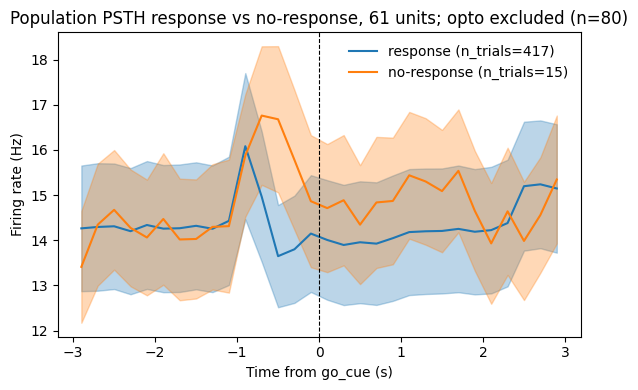

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Population PSTH response vs no-response, 61 units; opto excluded (n=80)'}, xlabel='Time from go_cue (s)', ylabel='Firing rate (Hz)'>)

In [46]:
# =============================================================================
# 7. POPULATION-AVERAGE PSTH: group A vs group B (all selected units)
# =============================================================================
from trial_outcome_psth import load_population_psth, build_groups, plot_population_psth

EXCLUDE_OPTO = True   # drop optogenetics (laser-on) trials from both groups

# Load the PSTH once and build the two trial groups; reused by sections 8-11.
pop = load_population_psth(psth, unit_ids, ALIGN_TO, TIME_WIN)
groups = build_groups(nwb, contrast, pop.avail_ids, opto_trial_ids, exclude_opto=EXCLUDE_OPTO)

plot_population_psth(
    pop, groups, contrast, align_to_event=ALIGN_TO,
    exclude_opto=EXCLUDE_OPTO, opto_n=len(opto_trial_ids),
    save_path=OUTDIR / f"population_psth_{contrast.tag}.png",
)


In [ ]:
# =============================================================================
# 7b. DIAGNOSE go_cue alignment: is spike_times on the SAME clock as goCue?
# =============================================================================
# A clean ~1 s shift of the population response for one session usually means the
# ephys spike_times and the behavior goCue_start_time are on slightly different
# clocks (sync issue), NOT a bug in the PSTH binning. This cell checks:
#   1) which ephys recording / session was used
#   2) whether the spike-time span overlaps the behavior-event span
#   3) the per-trial trial_start -> go_cue delay (should be stable, ~small)
#   4) where the population rate peaks when aligned to trial_start vs go_cue
import sys
from pathlib import Path
_MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")
if str(_MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(_MODULE_PATH))

import numpy as np
from behavior_utils import extract_event_timestamps

print(f"ephys_session used : {ephys_session}")
try:
    from nwb_utils import EPHYS_RECORDING_OVERRIDES
    from general_utils import extract_session_name_core
    _core = extract_session_name_core(ephys_session)
    print(f"recording override : {EPHYS_RECORDING_OVERRIDES.get(_core, 'experiment1_recording1 (default)')}")
except Exception as e:
    print(f"(could not read EPHYS_RECORDING_OVERRIDES: {e})")

# --- 1) Global spans: do spikes and behavior events live in the same window? --
sp_min, sp_max = np.inf, -np.inf
for u in unit_ids:
    s = np.asarray(nwb.units["spike_times"][u], dtype=float)
    if s.size:
        sp_min = min(sp_min, float(np.nanmin(s)))
        sp_max = max(sp_max, float(np.nanmax(s)))
go = np.asarray(extract_event_timestamps(nwb, "go_cue"), dtype=float)
st = np.asarray(nwb.trials["start_time"][:], dtype=float)

print("\n--- global time spans (seconds) ---")
print(f"spike_times : [{sp_min:10.2f}, {sp_max:10.2f}]  span={sp_max - sp_min:8.2f}")
print(f"go_cue      : [{np.nanmin(go):10.2f}, {np.nanmax(go):10.2f}]  span={np.nanmax(go) - np.nanmin(go):8.2f}")
print(f"trial_start : [{np.nanmin(st):10.2f}, {np.nanmax(st):10.2f}]")
# If go_cue falls well OUTSIDE [sp_min, sp_max] (or is offset by ~1s), that is a
# clock mismatch between ephys and behavior for this session.
print(f"fraction of go_cue BEFORE first spike : {float(np.mean(go < sp_min)):.3f}")
print(f"fraction of go_cue AFTER  last  spike : {float(np.mean(go > sp_max)):.3f}")

# --- 2) trial_start -> go_cue delay (sanity: should be stable & modest) -------
delay = go - st
print("\n--- trial_start -> go_cue delay (s) ---")
print(f"median={np.nanmedian(delay):.3f}  mean={np.nanmean(delay):.3f}  "
      f"min={np.nanmin(delay):.3f}  max={np.nanmax(delay):.3f}")

# --- 3) Where does the population rate peak, go_cue vs trial_start? -----------
# If the go_cue-aligned peak sits ~delay seconds BEFORE 0 and the trial_start-
# aligned peak sits at ~0, the neural response is actually locked to trial_start
# (or the go cue times are late by ~that delay).
from trial_outcome_psth import load_population_psth
for _evt in ("go_cue", "trial_start"):
    try:
        _p = load_population_psth(psth, unit_ids, _evt, TIME_WIN)
        _m = np.nanmean(_p.da.values, axis=(0, 1))   # mean over unit, trial -> time
        _t = np.asarray(_p.times)
        _pk = _t[int(np.nanargmax(_m))]
        print(f"population-rate peak aligned to {_evt:12s}: t = {_pk:+.2f} s")
    except Exception as e:
        print(f"(skip {_evt}: {e})")


In [ ]:
# =============================================================================
# 7c. DIAGNOSE go_cue TIMESTAMP source: soundcard go cue vs board-based events
# =============================================================================
# In the Bonsai->NWB conversion, goCue_start_time = B_GoCueTimeSoundCard (sound
# card), while start_time / delay_start_time come from the behavior board/Harp.
# If the soundcard timestamp drifts ~1 s for this session, go cue is offset from
# the spikes even though both are "on the Harp clock". We test this WITHOUT ephys
# using the trials table's own commanded durations:
#   (delay_start - start)  should ~= ITI_duration      (board vs board -> tight)
#   (goCue - delay_start)  should ~= delay_duration    (SOUNDCARD vs board)   <-- key
# Plus: licks cannot precede the REAL go cue, so if first-lick - goCue is often
# negative, the labeled go cue is late.
import numpy as np
from behavior_utils import extract_event_timestamps

tr = nwb.trials
cols = set(tr.colnames)
start = np.asarray(tr["start_time"][:], dtype=float)
go = np.asarray(tr["goCue_start_time"][:], dtype=float)
resp = np.asarray(tr["animal_response"][:], dtype=float)
laser = np.asarray(tr["laser_on_trial"][:], dtype=float) if "laser_on_trial" in cols else np.zeros_like(start)
delay_start = np.asarray(tr["delay_start_time"][:], dtype=float) if "delay_start_time" in cols else np.full_like(start, np.nan)
iti_dur = np.asarray(tr["ITI_duration"][:], dtype=float) if "ITI_duration" in cols else np.full_like(start, np.nan)
delay_dur = np.asarray(tr["delay_duration"][:], dtype=float) if "delay_duration" in cols else np.full_like(start, np.nan)

# non-opto trials with a valid delay-start timestamp
ok = (laser == 0) & np.isfinite(delay_start) & np.isfinite(go) & np.isfinite(start)

def _summ(name, measured, commanded, mask):
    d = (measured - commanded)[mask & np.isfinite(measured) & np.isfinite(commanded)]
    if d.size == 0:
        print(f"{name:28s}: (no valid trials)")
        return
    print(f"{name:28s}: n={d.size:4d}  median={np.median(d):+.3f}s  "
          f"mean={np.mean(d):+.3f}s  IQR=[{np.percentile(d,25):+.3f}, {np.percentile(d,75):+.3f}]")

print("--- measured interval  MINUS  commanded duration (should be ~0) ---")
_summ("ITI  (delay_start - start)", delay_start - start, iti_dur, ok)
_summ("delay (goCue - delay_start)", go - delay_start, delay_dur, ok)
print("  ^ if the 'delay' row is off by ~1 s but 'ITI' is ~0, the soundcard")
print("    goCue timestamp is late -> explains the PSTH shift (not neural).")

# --- lick-based reaction time: first lick around goCue (negative = impossible) --
try:
    licks = np.sort(np.asarray(extract_event_timestamps(nwb, "lick"), dtype=float))
    licks = licks[np.isfinite(licks)]
    rts = []
    resp_mask = ok & (resp != 2)
    for g in go[resp_mask]:
        w = licks[(licks >= g - 2.0) & (licks <= g + 3.0)]
        if w.size:
            rts.append(w[0] - g)          # first lick in window, relative to labeled goCue
    rts = np.asarray(rts)
    if rts.size:
        frac_neg = float(np.mean(rts < 0))
        print("\n--- first lick around goCue (response, non-opto trials) ---")
        print(f"n={rts.size}  median RT={np.median(rts):+.3f}s  "
              f"frac BEFORE goCue={frac_neg:.3f}  (mode near {np.median(rts):+.2f}s)")
        print("  Healthy session: RT>0, small positive mode. A large negative")
        print("  fraction / ~-1 s mode means the labeled go cue is late.")
    else:
        print("\n(no licks found near goCue to estimate reaction time)")
except Exception as e:
    print(f"\n(lick RT check skipped: {e})")


In [10]:
# =============================================================================
# 7d. Is the ~0.93 s offset = soundcard vs other go-cue timestamp sources?
# =============================================================================
# The NWB keeps only ONE go cue (goCue_start_time = B_GoCueTimeSoundCard). The
# raw Bonsai JSON also stores the behavior-board and CPU go-cue times. Load the
# raw JSON for THIS session and compare the per-trial go-cue sources directly:
#   soundcard - behavior_board   (does the sound lag the board command by ~0.93s?)
#   soundcard - cpu / harp       (other candidates)
# If one of these pairwise diffs matches the +0.93 s delay overshoot from 7c,
# the offset is purely a go-cue-timestamp-source difference, not neural/PSTH.
import json
import numpy as np
from pathlib import Path

RAW_JSON = Path(f"/root/capsule/data/ecephys_{session_date}/behavior/{session_date}.json")
print(f"raw behavior JSON: {RAW_JSON}")
assert RAW_JSON.exists(), f"raw JSON not found: {RAW_JSON}"

with open(RAW_JSON, "r") as _f:
    _raw = json.load(_f)

def _arr(key):
    v = _raw.get(key, None)
    if v is None:
        return None
    a = np.asarray(v, dtype=float).ravel()
    return a if a.size else None

# Candidate go-cue sources (per trial) + the board trial-start / delay refs.
_go_src = {
    "B_GoCueTimeSoundCard":     _arr("B_GoCueTimeSoundCard"),      # -> written to NWB
    "B_GoCueTimeBehaviorBoard": _arr("B_GoCueTimeBehaviorBoard"),  # board command
    "B_GoCueTime":              _arr("B_GoCueTime"),               # CPU time
    "B_GoCueTimeHarp":          _arr("B_GoCueTimeHarp"),           # old-format Harp
}
_has_harp = _raw.get("B_TrialEndTimeHarp", None) not in (None, [])
_tsuf = "Harp" if _has_harp else ""
_tstart = _arr(f"B_TrialStartTime{_tsuf}")
_dstart = _arr(f"B_DelayStartTime{_tsuf}")

print("\n--- available per-trial go-cue sources (n valid) ---")
for k, a in _go_src.items():
    print(f"  {k:26s}: {'absent' if a is None else f'{np.sum(np.isfinite(a))} / {a.size}'}")
print(f"  B_TrialStartTime{_tsuf:<10s}: {'absent' if _tstart is None else _tstart.size}")
print(f"  B_DelayStartTime{_tsuf:<10s}: {'absent' if _dstart is None else _dstart.size}")

def _pairdiff(a, b, la, lb):
    if a is None or b is None:
        print(f"  {la} - {lb:26s}: (one source absent)")
        return
    n = min(a.size, b.size)
    d = (a[:n] - b[:n])
    d = d[np.isfinite(d)]
    if d.size == 0:
        print(f"  {la} - {lb:26s}: (no overlapping finite trials)")
        return
    print(f"  {la} - {lb:26s}: n={d.size:4d}  median={np.median(d):+.3f}s  "
          f"mean={np.mean(d):+.3f}s  IQR=[{np.percentile(d,25):+.3f}, {np.percentile(d,75):+.3f}]")

print("\n--- pairwise go-cue source differences (seconds) ---")
_sc = _go_src["B_GoCueTimeSoundCard"]
_pairdiff(_sc, _go_src["B_GoCueTimeBehaviorBoard"], "soundcard", "behavior_board")
_pairdiff(_sc, _go_src["B_GoCueTime"],              "soundcard", "cpu")
_pairdiff(_sc, _go_src["B_GoCueTimeHarp"],          "soundcard", "harp")

# Which source equals the commanded delay-end (delay_start + delay_duration)?
_ddur = _arr("B_DelayHistory")
if _dstart is not None and _ddur is not None:
    _nd = min(_dstart.size, _ddur.size)   # some fields can be off-by-one
    _cmd_go = _dstart[:_nd] + _ddur[:_nd]
    print("\n--- each source MINUS commanded delay-end (delay_start + delay_duration) ---")
    for k, a in _go_src.items():
        if a is None:
            continue
        n = min(a.size, _cmd_go.size)
        d = (a[:n] - _cmd_go[:n])
        d = d[np.isfinite(d)]
        if d.size:
            print(f"  {k:26s}: median={np.median(d):+.3f}s  IQR=["
                  f"{np.percentile(d,25):+.3f}, {np.percentile(d,75):+.3f}]")
    print("  (the source nearest 0 here is the one locked to the commanded go time)")


raw behavior JSON: /root/capsule/data/ecephys_860083_2026-09-17_14-46-45/behavior/860083_2026-09-17_14-46-45.json

--- available per-trial go-cue sources (n valid) ---
  B_GoCueTimeSoundCard      : 512 / 512
  B_GoCueTimeBehaviorBoard  : 512 / 512
  B_GoCueTime               : 512 / 512
  B_GoCueTimeHarp           : absent
  B_TrialStartTimeHarp      : 512
  B_DelayStartTimeHarp      : 512

--- pairwise go-cue source differences (seconds) ---
  soundcard - behavior_board            : n= 512  median=+0.950s  mean=+0.951s  IQR=[+0.942, +0.960]
  soundcard - cpu                       : n= 512  median=+0.953s  mean=+0.953s  IQR=[+0.944, +0.963]
  soundcard - harp                      : (one source absent)

--- each source MINUS commanded delay-end (delay_start + delay_duration) ---
  B_GoCueTimeSoundCard      : median=+0.934s  IQR=[+0.925, +0.945]
  B_GoCueTimeBehaviorBoard  : median=-0.017s  IQR=[-0.017, -0.016]
  B_GoCueTime               : median=-0.019s  IQR=[-0.019, -0.018]
  (the sou

# 8. Scatter: group A vs group B mean rate (all selected units)

Per-unit scatter of the **mean firing rate within a selected time window** for
the two groups of the selected `CONTRAST`. Each point is one selected unit
(x = group A, y = group B). The dashed line is unity (y = x); points below it
fire more on group-A trials. Optogenetics (laser-on) trials are excluded by
default.

saved -> /root/capsule/scratch/raster_plot_units/872548_2026-10-01_14-13-15/tagged__all_probes/scatter_response_vs_noresponse.png


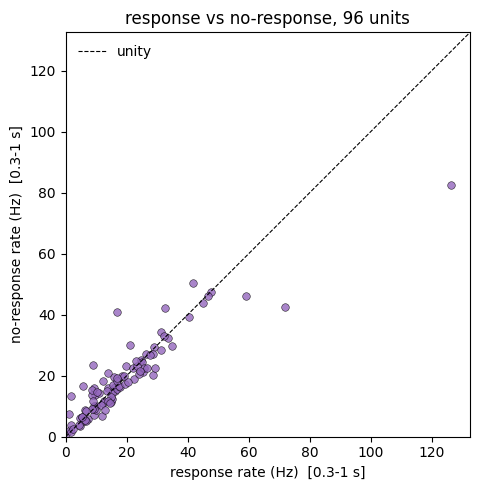

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'response vs no-response, 96 units'}, xlabel='response rate (Hz)  [0.3-1 s]', ylabel='no-response rate (Hz)  [0.3-1 s]'>)

In [15]:
# =============================================================================
# 8. SCATTER: group A vs group B windowed mean rate (all selected units)
# =============================================================================
from trial_outcome_psth import window_rates, plot_scatter

# Time window (seconds, relative to ALIGN_TO) over which to average the rate.
SCATTER_WIN = (0.3, 1)

# Per-unit mean rate in the window for each group (x = group A, y = group B).
x, y = window_rates(pop, groups, contrast, SCATTER_WIN)

plot_scatter(
    x, y, contrast, SCATTER_WIN, n_units=pop.n_units,
    exclude_opto=EXCLUDE_OPTO, opto_n=len(opto_trial_ids),
    save_path=OUTDIR / f"scatter_{contrast.tag}.png",
)


## 9. Paired per-unit difference (group B − group A)

Per unit, take the mean rate over `SCATTER_WIN` on each group, compute the signed
difference `B − A`, test it across units with a Wilcoxon signed-rank test, and
show the distribution of differences. A positive median indicates units fire
*more* on group-B trials in this window. Optogenetics (laser-on) trials follow
the `EXCLUDE_OPTO` toggle from the cells above.

n units (valid)          : 96
more on no-reward     : 45
more on reward        : 51
median (no-reward - reward) : -0.187 Hz
mean   (no-reward - reward) : -0.057 Hz
Wilcoxon signed-rank     : W=2319.0, p=0.974
saved -> /root/capsule/scratch/raster_plot_units/863015_2026-09-09_14-22-17/tagged__all_probes/paired_diff_reward_vs_noreward.png


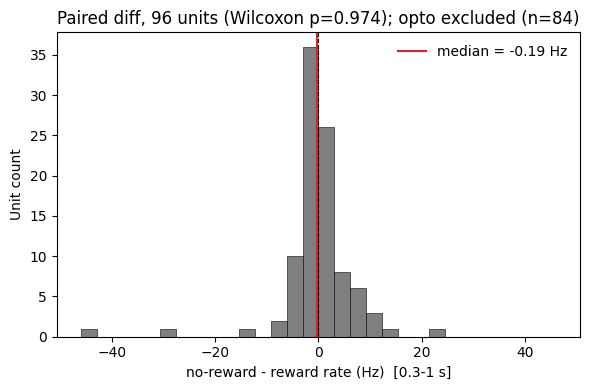

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Paired diff, 96 units (Wilcoxon p=0.974); opto excluded (n=84)'}, xlabel='no-reward - reward rate (Hz)  [0.3-1 s]', ylabel='Unit count'>)

In [39]:
# =============================================================================
# 9. Paired per-unit difference (group B - group A) + Wilcoxon signed-rank
# =============================================================================
from trial_outcome_psth import paired_diff, print_paired_diff, plot_paired_diff

stats = paired_diff(x, y)      # signed diff B - A per unit + Wilcoxon test
print_paired_diff(stats, contrast)

plot_paired_diff(
    stats, contrast, SCATTER_WIN,
    exclude_opto=EXCLUDE_OPTO, opto_n=len(opto_trial_ids),
    save_path=OUTDIR / f"paired_diff_{contrast.tag}.png",
)


## 10. Scatter colored by signed difference

Same group-A-vs-group-B scatter as section 8, but each unit is colored by its
signed difference `B − A` (diverging colormap centered at 0). Points above the
unity line are reddish (higher on group B), points below are bluish (higher on
group A), making any systematic shift easy to see.

saved -> /root/capsule/scratch/raster_plot_units/863973_2026-08-25_14-18-29/tagged__all_probes/scatter_reward_vs_noreward_colored_by_diff.png


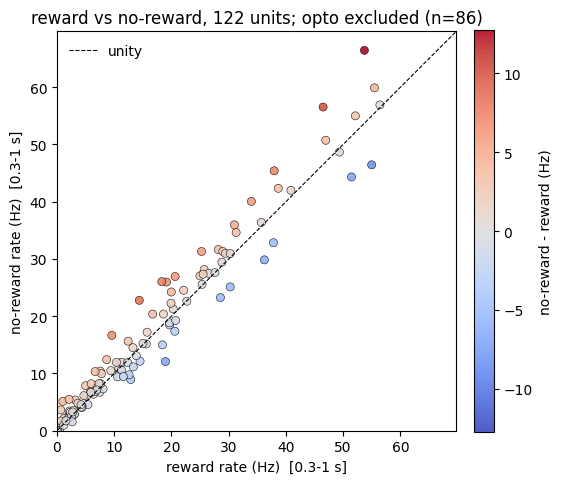

(<Figure size 560x500 with 2 Axes>,
 <Axes: title={'center': 'reward vs no-reward, 122 units; opto excluded (n=86)'}, xlabel='reward rate (Hz)  [0.3-1 s]', ylabel='no-reward rate (Hz)  [0.3-1 s]'>)

In [ ]:
# =============================================================================
# 10. Scatter colored by signed difference (group B - group A)
# =============================================================================
from trial_outcome_psth import plot_scatter_colored

plot_scatter_colored(
    x, y, stats["diff"], contrast, SCATTER_WIN, n_valid=stats["n_valid"],
    exclude_opto=EXCLUDE_OPTO, opto_n=len(opto_trial_ids),
    save_path=OUTDIR / f"scatter_{contrast.tag}_colored_by_diff.png",
)


## 11. Trial-count matched comparison

The two groups usually have very different trial counts, so the smaller group's
mean is estimated from far fewer trials. Here we repeatedly subsample the
**larger** group down to the **smaller** group's count, recompute the population
PSTH each time, and average across repeats. The matched larger-group PSTH is
plotted against the (fixed) smaller-group PSTH so any remaining separation is not
an artifact of unequal trial counts.

saved -> /root/capsule/scratch/raster_plot_units/863973_2026-08-25_14-18-29/tagged__all_probes/population_psth_trialcount_matched_reward_vs_noreward.png


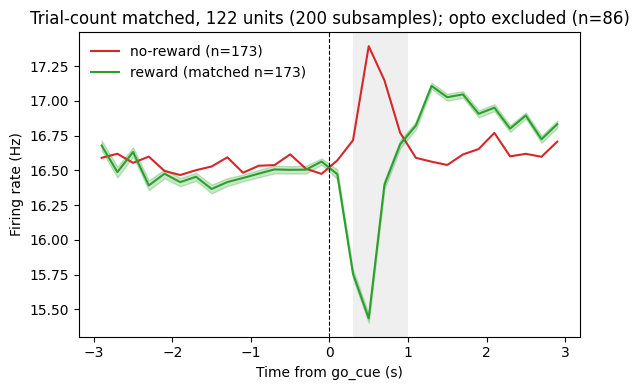

matched n per group            : 173
no-reward window rate       : 17.007 Hz
reward window rate (match) : 16.069 +/- 0.025 Hz
P(reward > no-reward)   : 0.000  (200 subsamples)


In [ ]:
# =============================================================================
# 11. Trial-count matched comparison (subsample the larger group to the smaller)
# =============================================================================
from trial_outcome_psth import trialcount_matched

res, _ = trialcount_matched(
    pop, groups, contrast, SCATTER_WIN, align_to_event=ALIGN_TO,
    n_boot=200, seed=0, exclude_opto=EXCLUDE_OPTO, opto_n=len(opto_trial_ids),
    save_path=OUTDIR / f"population_psth_trialcount_matched_{contrast.tag}.png",
)

print(f"matched n per group            : {res['n_match']}")
print(f"{res['small_label']} window rate       : {res['small_win']:.3f} Hz")
print(f"{res['big_label']} window rate (match) : {res['big_win_mean']:.3f} +/- {res['big_win_std']:.3f} Hz")
print(f"P({res['big_label']} > {res['small_label']})   : {res['frac_big_higher']:.3f}  ({res['n_boot']} subsamples)")
